# Motion Correction Demo

This notebook demonstrates the `spine_extraction` registration pipeline on a
single Bergamo two-photon TIFF recording. It walks through each stage:

1. Load and inspect the raw ScanImage TIFF
2. Run motion correction (strip registration)
3. Visualize motion traces and registered output
4. Compare with existing MATLAB results

In [1]:
# Auto-reload all modules so code changes take effect without restarting the kernel
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## 1. Load and inspect the raw TIFF

In [2]:
import os

from spine_extraction.io.tiff_reader import read_scanimage_tiff, reshape_interleaved

data_root = Path(os.environ["SPINE_TEST_DATA"])
tiff_path = data_root / "test_scan_00001_20240924_110500" / "scan_00001_20240924_110500.tif"
assert tiff_path.exists(), f"TIFF not found: {tiff_path}"

raw_data, metadata = read_scanimage_tiff(tiff_path)

print(f"Raw shape: {raw_data.shape}  (rows, cols, total_pages)")
print(f"Channels: {metadata.num_channels} ({metadata.channel_save})")
print(f"Frame rate: {metadata.frame_rate:.1f} Hz")
print(f"Frame time: {metadata.frame_time*1000:.2f} ms")
print(f"Frames per channel: {metadata.num_frames}")
print(f"File size: {tiff_path.stat().st_size / 1e9:.2f} GB")

Raw shape: (50, 128, 337066)  (rows, cols, total_pages)
Channels: 2 ([2, 4])
Frame rate: 429.9 Hz
Frame time: 2.33 ms
Frames per channel: 168533
File size: 5.12 GB


Reshaped movie: (46, 128, 2, 168533)  (rows, cols, channels, frames)


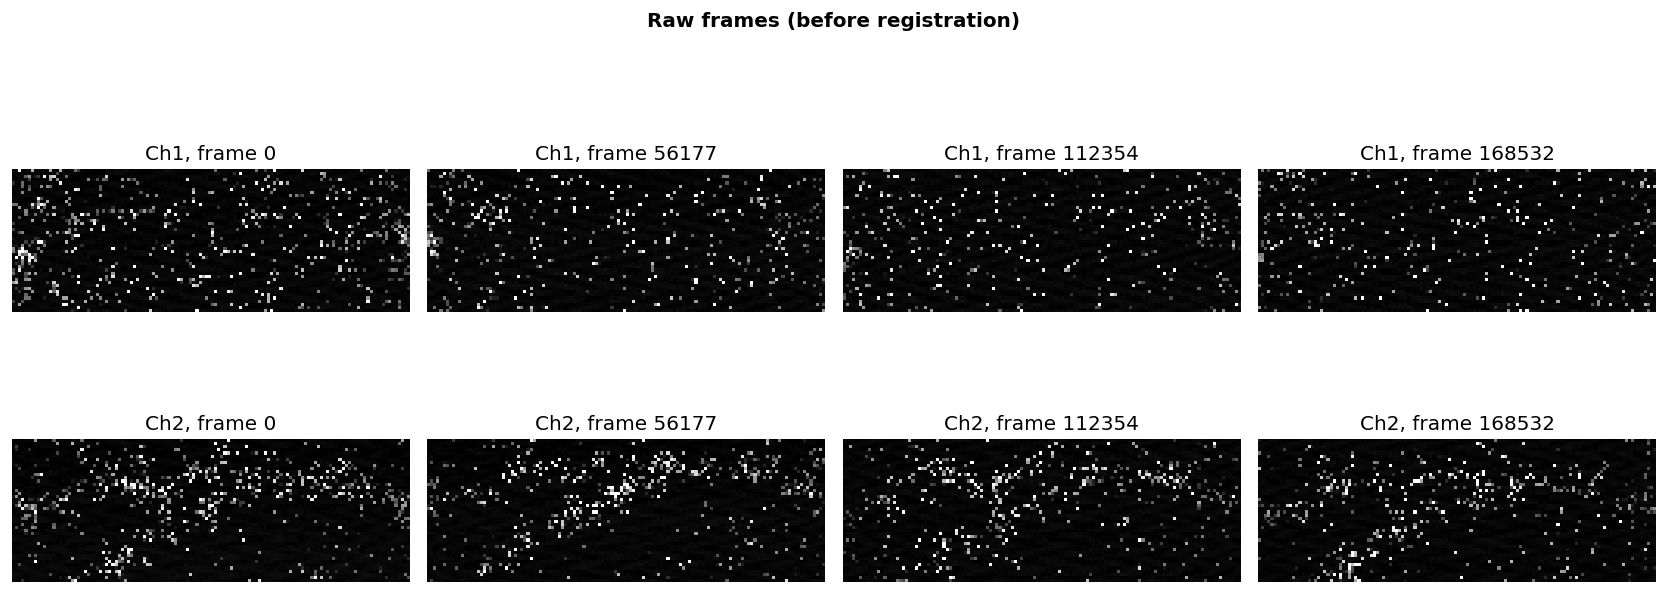

In [3]:
# Reshape into (rows, cols, channels, frames) and remove flyback lines
remove_lines = 4
movie = reshape_interleaved(raw_data, metadata.num_channels, remove_lines=remove_lines)
print(f"Reshaped movie: {movie.shape}  (rows, cols, channels, frames)")

# Show a few raw frames from each channel
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
sample_frames = np.linspace(0, movie.shape[3] - 1, 4, dtype=int)
for ch in range(min(2, movie.shape[2])):
    for i, f in enumerate(sample_frames):
        ax = axes[ch, i]
        ax.imshow(movie[:, :, ch, f], cmap="gray", vmin=np.nanpercentile(movie[:, :, ch, f], 5),
                  vmax=np.nanpercentile(movie[:, :, ch, f], 99))
        ax.set_title(f"Ch{ch+1}, frame {f}")
        ax.axis("off")
fig.suptitle("Raw frames (before registration)", fontweight="bold")
plt.tight_layout()

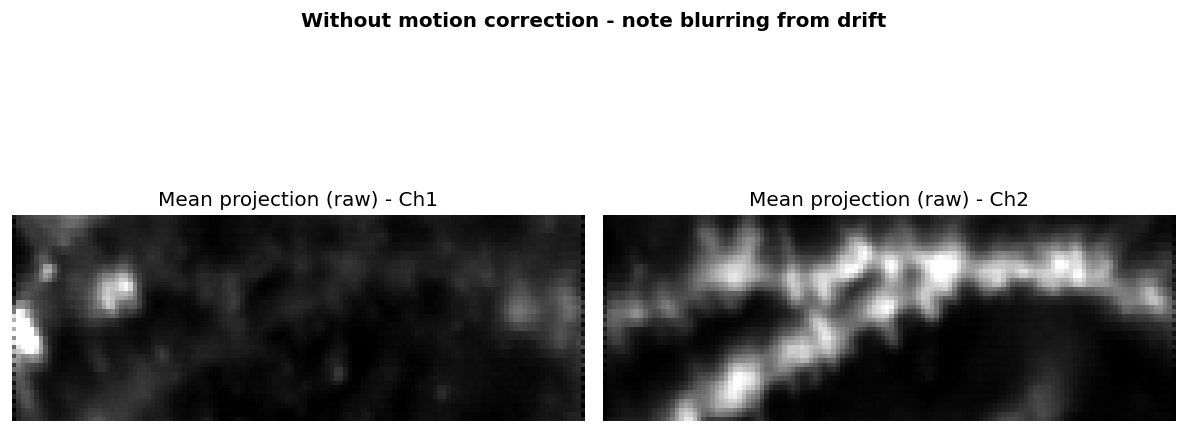

In [4]:
# Simple mean projection (no motion correction)
mean_raw = np.nanmean(movie, axis=3)

fig, axes = plt.subplots(1, metadata.num_channels, figsize=(5 * metadata.num_channels, 5))
if metadata.num_channels == 1:
    axes = [axes]
for ch in range(metadata.num_channels):
    im = mean_raw[:, :, ch]
    axes[ch].imshow(im, cmap="gray", vmin=np.nanpercentile(im, 1), vmax=np.nanpercentile(im, 99.5))
    axes[ch].set_title(f"Mean projection (raw) - Ch{ch+1}")
    axes[ch].axis("off")
plt.suptitle("Without motion correction - note blurring from drift", fontweight="bold")
plt.tight_layout()

# Free the reshaped movie but keep raw_data + metadata for registration
del movie, mean_raw

## 2. Run motion correction

The registration pipeline:
1. Subtracts a baseline (10th percentile)
2. Builds an initial template via hierarchical clustering of the first 1000 downsampled frames
3. Registers each frame via FFT cross-correlation with sub-pixel refinement
4. Computes alignment quality metrics
5. Upsamples motion vectors and writes registered data to Zarr

In [5]:
import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(name)s %(levelname)s: %(message)s", datefmt="%Y-%m-%d %H:%M:%S")

In [6]:
from spine_extraction.config import RegistrationConfig
from spine_extraction.io.trial_table import TrialTable, TrialEntry
from spine_extraction.io.zarr_store import ExperimentStore
from spine_extraction.registration.bergamo import register_bergamo

# Configure registration
config = RegistrationConfig(
    maxshift=50,
    clip_shift=10,
    remove_lines=4,
    ds_time=3,          # downsample by 2^3 = 8x
    n_workers=1,        # single trial, no need for multiprocessing
    init_frames=1000,
    min_cluster_size=100,
    save_full_resolution=True,  # needed for NMF extraction (tau_s=0.03s requires ~430 Hz)
)

# Build a single-trial table
data_dir = tiff_path.parent
tt = TrialTable(
    directory=str(data_dir),
    entries=[TrialEntry(filename=tiff_path.name, trial_index=1, epoch=1)],
)

# Output Zarr store next to the original TIFF
store = ExperimentStore(data_dir / "registered.zarr")

print(f"Data directory: {data_dir}")
print(f"Output Zarr:    {data_dir / 'registered.zarr'}")
print(f"Config: ds_factor={config.ds_factor}, maxshift={config.maxshift}, clip_shift={config.clip_shift}")
print(f"save_full_resolution={config.save_full_resolution}")

2026-03-06 11:23:04 spine_extraction.io.zarr_store INFO: Opened Zarr store at C:\Users\user\Desktop\iGluSnFR test data\750098\2024-09-24\test_scan_00001_20240924_110500\registered.zarr


Data directory: C:\Users\user\Desktop\iGluSnFR test data\750098\2024-09-24\test_scan_00001_20240924_110500
Output Zarr:    C:\Users\user\Desktop\iGluSnFR test data\750098\2024-09-24\test_scan_00001_20240924_110500\registered.zarr
Config: ds_factor=8, maxshift=50, clip_shift=10
save_full_resolution=True


In [7]:
%%time
import torch

# if torch.cuda.is_available():
#     device = torch.device("cuda")
#     print(f"Using GPU: {torch.cuda.get_device_name(0)}")
# else:
#     device = torch.device("cpu")
#     print("Using CPU (numpy-optimized FFT path)")

# Run registration (pass pre-loaded data to skip TIFF re-read)
device = "cpu"
tt = register_bergamo(tt, config, store, device=device, raw_data=raw_data, metadata=metadata)

2026-03-06 11:23:05 spine_extraction._utils.parallel INFO: Using 1 workers (requested=1, memory-limited=0, trials=1)
2026-03-06 11:23:05 spine_extraction.registration.bergamo INFO: Registering 1 trials with 1 workers
2026-03-06 11:23:05 spine_extraction.registration.bergamo INFO: Aligning trial 1: scan_00001_20240924_110500.tif
2026-03-06 11:23:05 spine_extraction.registration.bergamo INFO: Using pre-loaded data, skipping TIFF read
2026-03-06 11:23:10 spine_extraction.registration.template INFO: Creating initial template from 1000 frames
2026-03-06 11:23:10 spine_extraction.registration.template INFO: Selected cluster with 143 frames (mean correlation 0.4226)
2026-03-06 11:23:12 spine_extraction.registration.template INFO: Initial template created: shape (146, 228)
2026-03-06 11:23:13 spine_extraction.registration.bergamo INFO: Pre-computed 21066 downsampled frames
2026-03-06 11:23:13 spine_extraction.registration.bergamo INFO: Registering 21066 downsampled frames on CPU (numpy-optimiz

CPU times: total: 16min 31s
Wall time: 2min 7s


## 3. Inspect registration results

In [8]:
# Load alignment data from Zarr
adata = store.load_alignment_data(1)

print(f"Channels: {adata.num_channels}")
print(f"Frame time: {adata.frame_time*1000:.2f} ms")
print(f"Align Hz (downsampled): {adata.align_hz:.1f} Hz")
print(f"Motion vectors (full-res): {len(adata.motion_r)} frames")
print(f"Motion vectors (downsampled): {len(adata.motion_ds_r)} frames")
print(f"Max row motion: {np.nanmax(np.abs(adata.motion_r)):.2f} px")
print(f"Max col motion: {np.nanmax(np.abs(adata.motion_c)):.2f} px")

Channels: 2
Frame time: 2.33 ms
Align Hz (downsampled): 53.7 Hz
Motion vectors (full-res): 168528 frames
Motion vectors (downsampled): 21066 frames
Max row motion: 19.25 px
Max col motion: 15.74 px


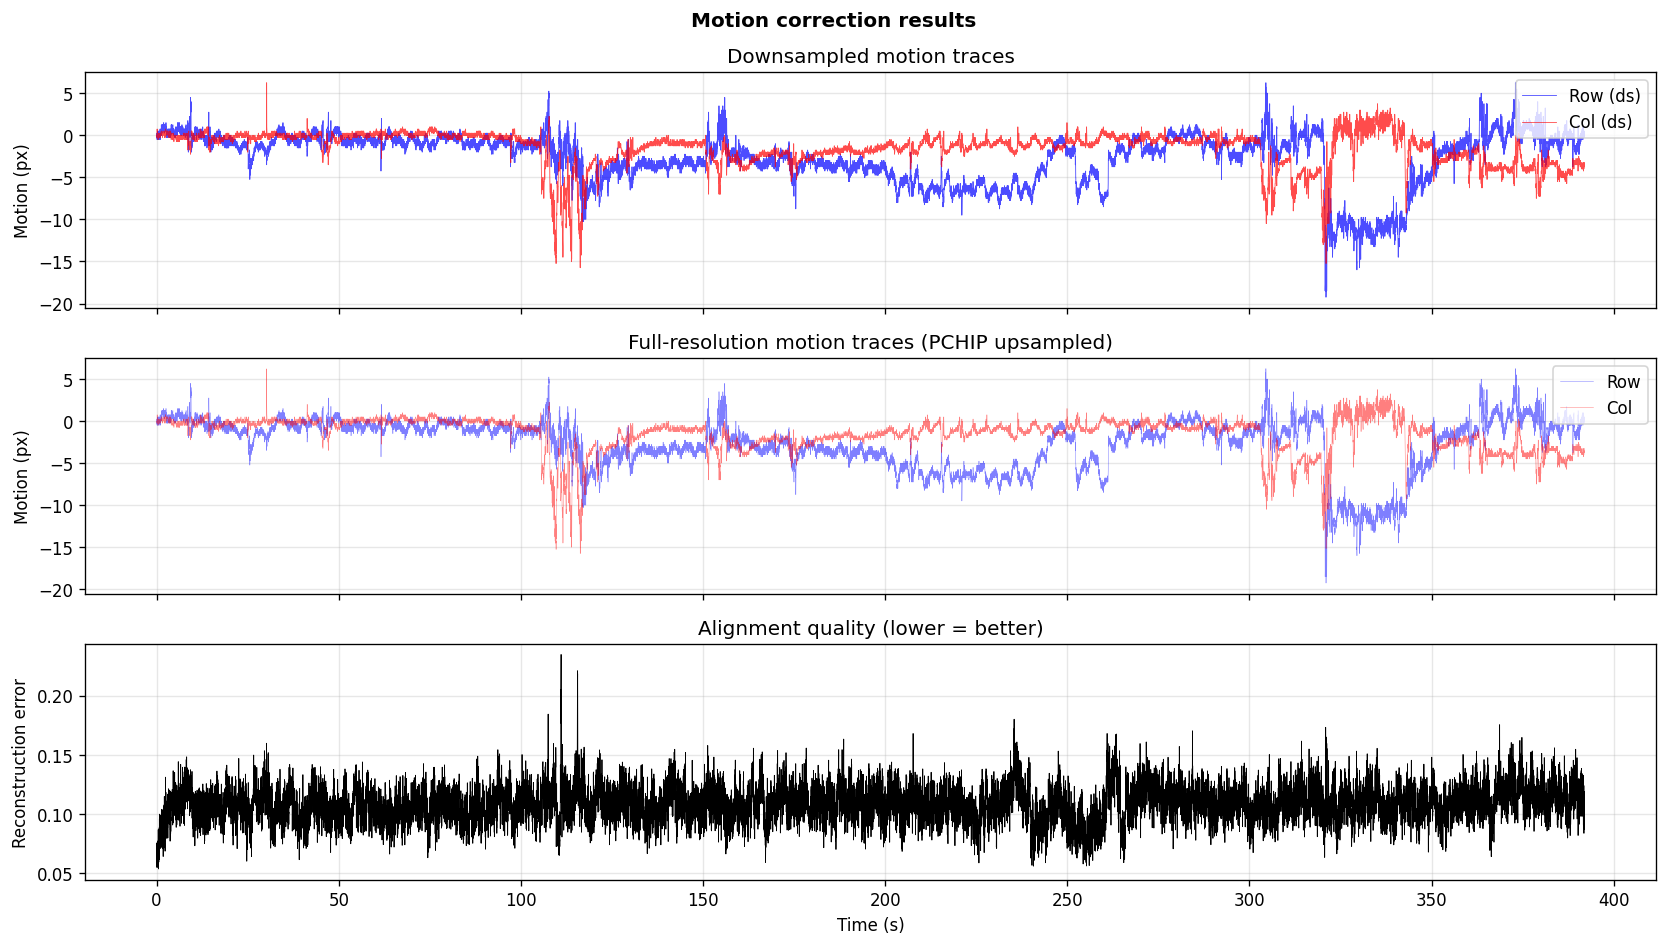

In [9]:
# Plot motion traces
t_ds = np.arange(len(adata.motion_ds_r)) / adata.align_hz
t_full = np.arange(len(adata.motion_r)) * adata.frame_time

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(t_ds, adata.motion_ds_r, "b-", lw=0.5, alpha=0.7, label="Row (ds)")
axes[0].plot(t_ds, adata.motion_ds_c, "r-", lw=0.5, alpha=0.7, label="Col (ds)")
axes[0].set_ylabel("Motion (px)")
axes[0].set_title("Downsampled motion traces")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_full, adata.motion_r, "b-", lw=0.3, alpha=0.5, label="Row")
axes[1].plot(t_full, adata.motion_c, "r-", lw=0.3, alpha=0.5, label="Col")
axes[1].set_ylabel("Motion (px)")
axes[1].set_title("Full-resolution motion traces (PCHIP upsampled)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_ds, adata.rec_neg_err, "k-", lw=0.5)
axes[2].set_ylabel("Reconstruction error")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Alignment quality (lower = better)")
axes[2].grid(True, alpha=0.3)

fig.suptitle("Motion correction results", fontweight="bold")
plt.tight_layout()

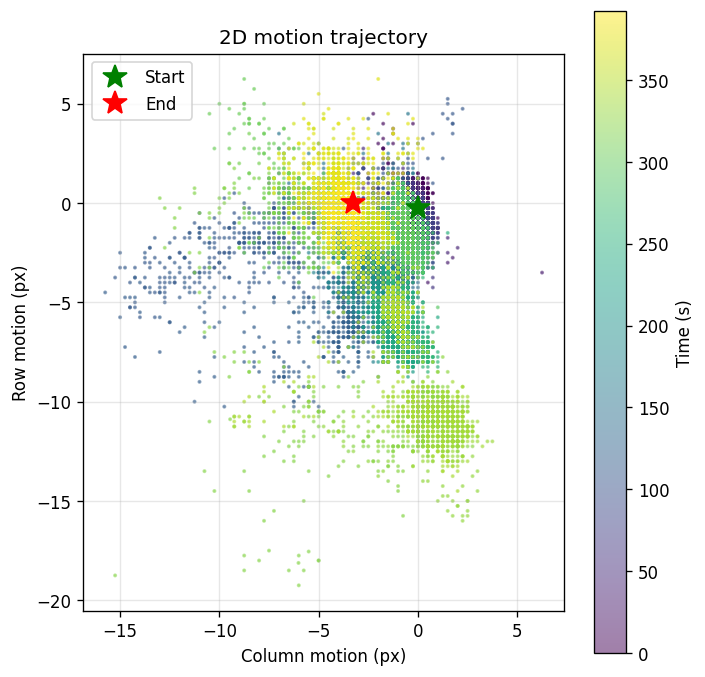

In [10]:
# 2D motion trajectory
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(adata.motion_ds_c, adata.motion_ds_r, c=t_ds, cmap="viridis", s=2, alpha=0.5)
ax.plot(adata.motion_ds_c[0], adata.motion_ds_r[0], "g*", ms=15, label="Start")
ax.plot(adata.motion_ds_c[-1], adata.motion_ds_r[-1], "r*", ms=15, label="End")
ax.set_xlabel("Column motion (px)")
ax.set_ylabel("Row motion (px)")
ax.set_title("2D motion trajectory")
ax.legend()
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label="Time (s)")
plt.tight_layout()

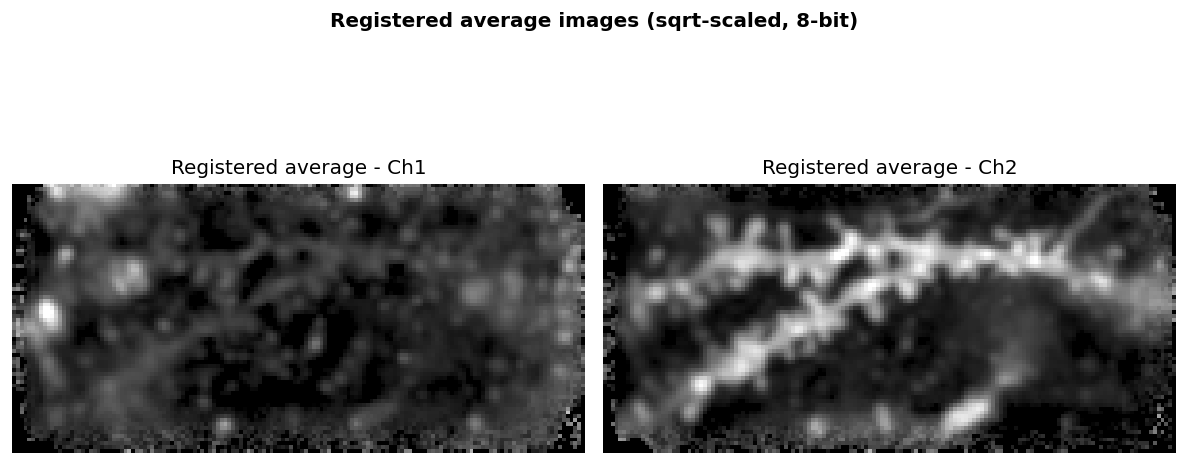

In [11]:
# Load and display registered average images
import zarr

trial_grp = store.root["trials/trial_001"]
n_ch = adata.num_channels

fig, axes = plt.subplots(1, n_ch, figsize=(5 * n_ch, 5))
if n_ch == 1:
    axes = [axes]
for ch in range(n_ch):
    key = f"avg_images/ch{ch+1}_8bit"
    if key in trial_grp:
        img = np.array(trial_grp[key])
        axes[ch].imshow(img, cmap="gray")
        axes[ch].set_title(f"Registered average - Ch{ch+1}")
    else:
        axes[ch].set_title(f"Ch{ch+1} - not found")
    axes[ch].axis("off")
plt.suptitle("Registered average images (sqrt-scaled, 8-bit)", fontweight="bold")
plt.tight_layout()

Registered downsampled shape: (70, 149, 42132)  (rows, cols, ds_frames * n_ch)


C:\Users\user\AppData\Local\Temp\ipykernel_198412\1198236065.py:10: RuntimeWarning: Mean of empty slice
  mean_reg = np.nanmean(reg_4d, axis=3)


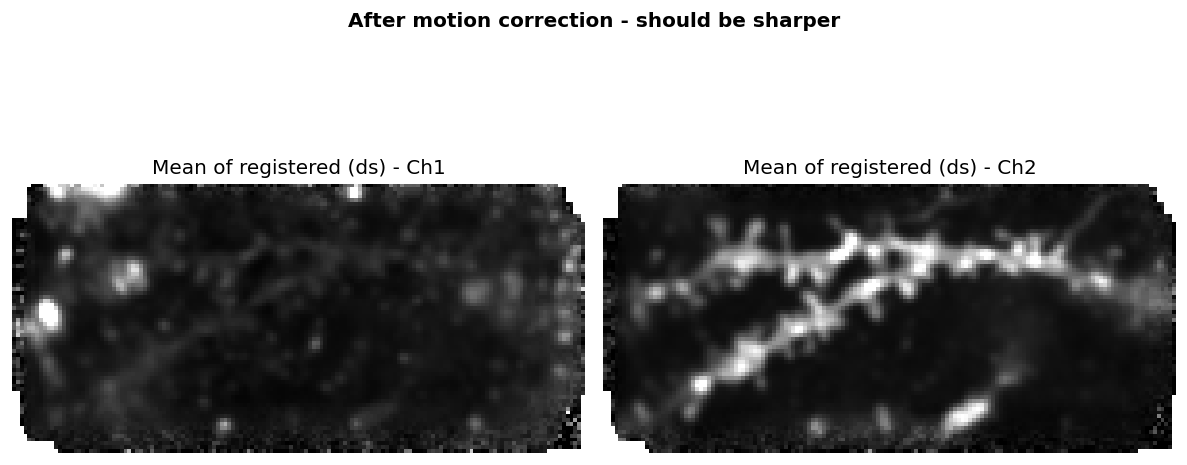

In [12]:
# Load downsampled registered movie and show a few frames
reg_ds = store.load_registered_ds(1)
print(f"Registered downsampled shape: {reg_ds.shape}  (rows, cols, ds_frames * n_ch)")

n_ds_frames = reg_ds.shape[2] // n_ch
# Deinterleave: stored as [ch0_t0, ch1_t0, ch0_t1, ch1_t1, ...] along axis 2
reg_4d = reg_ds.reshape(reg_ds.shape[0], reg_ds.shape[1], n_ds_frames, n_ch).transpose(0, 1, 3, 2)

# Show registered mean
mean_reg = np.nanmean(reg_4d, axis=3)

fig, axes = plt.subplots(1, n_ch, figsize=(5 * n_ch, 5))
if n_ch == 1:
    axes = [axes]
for ch in range(n_ch):
    im = mean_reg[:, :, ch]
    axes[ch].imshow(im, cmap="gray", vmin=np.nanpercentile(im, 1), vmax=np.nanpercentile(im, 99.5))
    axes[ch].set_title(f"Mean of registered (ds) - Ch{ch+1}")
    axes[ch].axis("off")
plt.suptitle("After motion correction - should be sharper", fontweight="bold")
plt.tight_layout()

## 4. Compare with MATLAB results

The same recording was previously processed with the MATLAB pipeline. Let's compare
the motion vectors and average images.

In [13]:
import scipy.io

# Load MATLAB alignment data
matlab_align_path = data_dir / (tiff_path.stem + "_ALIGNMENTDATA.mat")
if matlab_align_path.exists():
    mat = scipy.io.loadmat(str(matlab_align_path))
    print("MATLAB alignment data keys:", [k for k in mat.keys() if not k.startswith("__")])
    
    # Extract MATLAB motion vectors
    matlab_motion = mat.get("motion", mat.get("motionXY", None))
    if matlab_motion is not None:
        print(f"MATLAB motion shape: {matlab_motion.shape}")
else:
    print(f"MATLAB alignment data not found at: {matlab_align_path}")
    print("Skipping comparison.")

MATLAB alignment data not found at: C:\Users\user\Desktop\iGluSnFR test data\750098\2024-09-24\test_scan_00001_20240924_110500\scan_00001_20240924_110500_ALIGNMENTDATA.mat
Skipping comparison.


In [14]:
# Compare average images if MATLAB registered TIFF is available
matlab_avg_ch1 = data_dir / (tiff_path.stem + "_REGISTERED_AVG_CH1_8bit.tif")
matlab_avg_ch2 = data_dir / (tiff_path.stem + "_REGISTERED_AVG_CH2_8bit.tif")

import tifffile

matlab_avgs = {}
for ch, path in enumerate([matlab_avg_ch1, matlab_avg_ch2], 1):
    if path.exists():
        matlab_avgs[ch] = tifffile.imread(str(path))
        print(f"MATLAB avg Ch{ch}: shape={matlab_avgs[ch].shape}, dtype={matlab_avgs[ch].dtype}")

if matlab_avgs:
    n_compare = len(matlab_avgs)
    fig, axes = plt.subplots(2, n_compare, figsize=(5 * n_compare, 10))
    if n_compare == 1:
        axes = axes[:, np.newaxis]
    
    for i, (ch, mat_img) in enumerate(matlab_avgs.items()):
        # MATLAB result
        axes[0, i].imshow(mat_img, cmap="gray")
        axes[0, i].set_title(f"MATLAB - Ch{ch}")
        axes[0, i].axis("off")
        
        # Python result
        key = f"avg_images/ch{ch}_8bit"
        if key in trial_grp:
            py_img = np.array(trial_grp[key])
            axes[1, i].imshow(py_img, cmap="gray")
            axes[1, i].set_title(f"Python - Ch{ch}")
        else:
            axes[1, i].set_title(f"Python Ch{ch} - not found")
        axes[1, i].axis("off")
    
    plt.suptitle("MATLAB vs Python registered averages", fontweight="bold")
    plt.tight_layout()
else:
    print("No MATLAB average images found for comparison.")

No MATLAB average images found for comparison.


## 5. Explore the Zarr store

In [15]:
# Print the Zarr hierarchy
def print_zarr_tree(group, prefix=""):
    for name in sorted(group.keys()):
        item = group[name]
        if isinstance(item, zarr.Group):
            print(f"{prefix}{name}/")
            print_zarr_tree(item, prefix + "  ")
        else:
            print(f"{prefix}{name}: {item.shape} {item.dtype}")

print("Zarr store contents:")
print_zarr_tree(store.root)

Zarr store contents:
trials/
  trial_001/
    alignment/
      motion_c: (168528,) float64
      motion_ds_c: (21066,) float64
      motion_ds_r: (21066,) float64
      motion_r: (168528,) float64
      rec_neg_err: (21066,) float64
    avg_images/
      ch1_8bit: (70, 149) uint8
      ch2_8bit: (70, 149) uint8
    registered_ds: (70, 149, 42132) float32
    registered_raw: (70, 149, 337056) float32


In [16]:
# Summary statistics
motion_magnitude = np.sqrt(adata.motion_ds_r**2 + adata.motion_ds_c**2)

print("=== Registration Summary ===")
print(f"Total frames registered: {len(adata.motion_r)}")
print(f"Recording duration: {len(adata.motion_r) * adata.frame_time:.1f} s")
print(f"Mean motion magnitude: {np.nanmean(motion_magnitude):.2f} px")
print(f"Max motion magnitude:  {np.nanmax(motion_magnitude):.2f} px")
print(f"Median recon error:    {np.nanmedian(adata.rec_neg_err):.4f}")
print(f"Frames with high error (>2x median): {np.sum(adata.rec_neg_err > 2 * np.nanmedian(adata.rec_neg_err))}")

=== Registration Summary ===
Total frames registered: 168528
Recording duration: 392.0 s
Mean motion magnitude: 3.87 px
Max motion magnitude:  24.17 px
Median recon error:    0.1082
Frames with high error (>2x median): 4
